# MobileNetV2 — Building the Concept From the Ground Up

This notebook explains **MobileNetV2** one idea at a time. Each cell introduces a single
concept and (where useful) demonstrates it with runnable code, so that by the end you
understand *why* it is the go-to backbone for **transfer learning** on small image
datasets like **NEU-DET steel surface defects**.

**Path of ideas:**
1. The problem: convolutions are expensive
2. Depthwise separable convolution (the core trick)
3. Inverted residuals + linear bottlenecks
4. ReLU6 and why linear bottlenecks
5. Width & resolution multipliers (tunable size)
6. Loading the real pretrained MobileNetV2
7. Using it as a frozen feature extractor
8. Building a transfer-learning head for 6 defect classes

## 0. Setup

We only need TensorFlow/Keras, NumPy and Matplotlib. Everything below runs on CPU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)

I0000 00:00:1784994080.263800   60397 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784994080.700615   60397 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784994085.547992   60397 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


## 1. Why do we even need MobileNet? Convolutions are expensive

A **standard convolution** with a `k x k` kernel that maps `Cin` input channels to
`Cout` output channels, over a feature map of size `H x W`, costs:

$$\text{Cost}_{std} = H \cdot W \cdot C_{in} \cdot C_{out} \cdot k \cdot k$$

Every output channel looks at **every** input channel **and** every spatial position at once.
That single multiplicative term `Cin * Cout * k * k` is what makes big CNNs heavy — too
heavy for phones, edge devices, or a factory inspection camera.

Let's put a number on it.

In [2]:
def std_conv_cost(H, W, Cin, Cout, k):
    return H * W * Cin * Cout * k * k

# Example layer: 14x14 feature map, 256 -> 256 channels, 3x3 kernel
cost = std_conv_cost(14, 14, 256, 256, 3)
print(f"Standard 3x3 conv multiply-adds: {cost:,}")

Standard 3x3 conv multiply-adds: 115,605,504


## 2. The core trick: Depthwise Separable Convolution

MobileNet **factorises** one expensive convolution into two cheap steps:

1. **Depthwise conv** — one `k x k` filter *per input channel* (channels do NOT mix).
   Cost: `H*W*Cin*k*k`
2. **Pointwise conv** — a `1 x 1` convolution that mixes channels to produce `Cout`.
   Cost: `H*W*Cin*Cout`

Instead of doing "filter spatially" and "mix channels" in one shot, it does them
**separately**. The combined cost is:

$$\text{Cost}_{dw} = H\cdot W\cdot C_{in}\cdot k\cdot k \;+\; H\cdot W\cdot C_{in}\cdot C_{out}$$

The reduction factor vs. a standard conv is roughly:

$$\frac{1}{C_{out}} + \frac{1}{k^2}$$

For a 3x3 kernel that is about **8–9x fewer** computations for nearly the same modelling power.

In [3]:
def dw_sep_cost(H, W, Cin, Cout, k):
    depthwise = H * W * Cin * k * k
    pointwise = H * W * Cin * Cout
    return depthwise + pointwise

std = std_conv_cost(14, 14, 256, 256, 3)
sep = dw_sep_cost(14, 14, 256, 256, 3)

print(f"Standard conv : {std:,}")
print(f"Depthwise sep : {sep:,}")
print(f"Reduction     : {std/sep:.1f}x cheaper")
print(f"Theory (1/Cout + 1/k^2) -> {(1/256 + 1/9):.4f} of the cost")

Standard conv : 115,605,504
Depthwise sep : 13,296,640
Reduction     : 8.7x cheaper
Theory (1/Cout + 1/k^2) -> 0.1150 of the cost


### See it in a real Keras layer count

We can build both a standard conv and a depthwise-separable conv in Keras and compare
the number of **trainable parameters** — the same story shows up in parameters, not just FLOPs.

In [4]:
inp = layers.Input(shape=(14, 14, 256))

# Standard conv
std_out = layers.Conv2D(256, 3, padding="same")(inp)
std_model = models.Model(inp, std_out)

# Depthwise separable = DepthwiseConv2D + 1x1 Conv2D
dw = layers.DepthwiseConv2D(3, padding="same")(inp)
pw = layers.Conv2D(256, 1, padding="same")(dw)
sep_model = models.Model(inp, pw)

print("Standard conv params      :", f"{std_model.count_params():,}")
print("Depthwise separable params:", f"{sep_model.count_params():,}")

Standard conv params      : 590,080
Depthwise separable params: 68,352


E0000 00:00:1784994089.432793   60397 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 3. Inverted Residuals + Linear Bottlenecks (what makes it *V2*)

MobileNet**V1** was just stacks of depthwise-separable convs. **V2** adds two ideas that
form its signature building block — the **inverted residual bottleneck**:

**Normal residual block (ResNet):** wide → **narrow** → wide, skip connects the *wide* ends.

**Inverted residual (MobileNetV2):** narrow → **wide** → narrow, skip connects the *narrow* ends.

Each block does three things:
1. **Expand** — a 1x1 conv blows the channels up by an *expansion factor* `t` (usually 6).
2. **Depthwise** — a 3x3 depthwise conv filters spatially in this high-dimensional space (cheap, because it's depthwise).
3. **Project** — a 1x1 conv squeezes back down to a small number of channels (the "bottleneck").

The **residual skip** connects the thin bottleneck tensors (in→out) *when* their shapes match
(stride 1 and same channels). Keeping the tensors that travel between blocks *thin* is what
keeps memory and compute low; the expansion happens only *inside* the block.

In [5]:
def inverted_residual_block(x, in_ch, out_ch, stride=1, expand=6):
    inputs = x
    # 1) Expand channels with 1x1 conv
    ex = layers.Conv2D(in_ch * expand, 1, padding="same", use_bias=False)(x)
    ex = layers.BatchNormalization()(ex)
    ex = layers.ReLU(6.0)(ex)                 # ReLU6 (next section)
    # 2) Depthwise 3x3 spatial filtering in the expanded space
    dw = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False)(ex)
    dw = layers.BatchNormalization()(dw)
    dw = layers.ReLU(6.0)(dw)
    # 3) Project back down to a thin bottleneck -- NOTE: no activation here (linear!)
    pr = layers.Conv2D(out_ch, 1, padding="same", use_bias=False)(dw)
    pr = layers.BatchNormalization()(pr)
    # Residual skip only when shapes match
    if stride == 1 and in_ch == out_ch:
        pr = layers.Add()([inputs, pr])
    return pr

x_in = layers.Input(shape=(56, 56, 24))
y = inverted_residual_block(x_in, in_ch=24, out_ch=24, stride=1, expand=6)
block = models.Model(x_in, y)
block.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 56, 56,    │          0 │ -                 │
│ (InputLayer)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      3,456 │ input_layer_1[0]… │
│                     │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 56, 56,    │        576 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 56, 56,    │      1,296 │ re_lu[0][0]       │
│ (DepthwiseConv2D)   │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        576 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │      3,456 │ re_lu_1[0][0]     │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ input_layer_1[0]… │
│                     │ 24)               │            │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,456 (36.94 KB)

 Trainable params: 8,832 (34.50 KB)

 Non-trainable params: 624 (2.44 KB)

## 4. ReLU6 and the "Linear" Bottleneck

Two deliberate choices in that block:

**ReLU6** = `min(max(0, x), 6)`. The activation is capped at 6. This bounded range keeps
values in a small, robust window — important for **low-precision (int8) inference** on
mobile/edge hardware, where large activations would lose accuracy when quantised.

**Linear bottleneck** = the final *projection* conv has **no activation function**.
Why? The bottleneck tensors are low-dimensional. Applying ReLU in a low-dimensional space
**destroys information** (it zeroes out negatives you can't recover). Keeping the projection
*linear* preserves the information flowing between blocks. This was a key V2 insight.

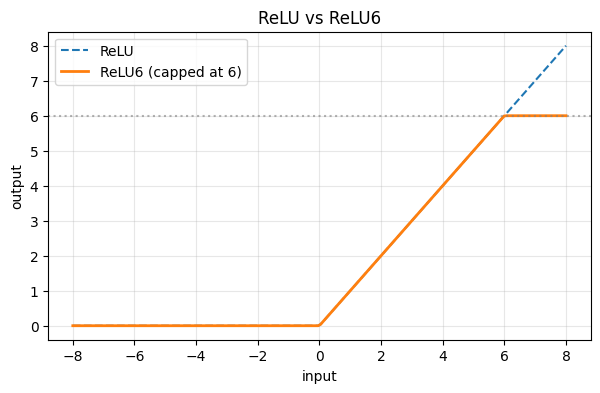

In [6]:
x = np.linspace(-8, 8, 200)
relu   = np.maximum(0, x)
relu6  = np.minimum(np.maximum(0, x), 6)

plt.figure(figsize=(7,4))
plt.plot(x, relu,  "--", label="ReLU")
plt.plot(x, relu6, label="ReLU6 (capped at 6)", linewidth=2)
plt.axhline(6, color="gray", ls=":", alpha=0.6)
plt.title("ReLU vs ReLU6"); plt.xlabel("input"); plt.ylabel("output")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. Width & Resolution Multipliers — one architecture, many sizes

MobileNetV2 exposes two knobs so you can trade accuracy for speed/size:

- **Width multiplier `alpha`** — scales the number of channels in every layer.
  `alpha=1.0` is the full model; `alpha=0.35` is a tiny model. Fewer channels → fewer params.
- **Resolution** — the input image size (e.g. 224, 192, 160, 128). Smaller input → fewer
  spatial computations (cost scales with `H*W`).

This is why you'll see names like *MobileNetV2 1.0 224*. Let's compare parameter counts.

In [7]:
from tensorflow.keras.applications import MobileNetV2

for alpha in [0.35, 0.75, 1.0]:
    m = MobileNetV2(input_shape=(224,224,3), alpha=alpha,
                    include_top=False, weights=None)
    print(f"alpha={alpha:<4}  ->  {m.count_params():,} params")

alpha=0.35  ->  410,208 params


alpha=0.75  ->  1,382,064 params


alpha=1.0   ->  2,257,984 params


## 6. Load the REAL pretrained MobileNetV2

Now the payoff. Keras ships MobileNetV2 pretrained on **ImageNet** (1.4M images, 1000 classes).
Those learned filters already detect edges, textures, and patterns — exactly the low-level
features that also describe **steel surface defects**. That is the essence of transfer learning:
reuse this visual knowledge instead of learning it from scratch.

- `weights="imagenet"` → download the pretrained weights.
- `include_top=False` → drop the 1000-class ImageNet classifier; we'll add our own head.
- `input_shape=(224,224,3)` → the standard input the weights were trained on.

In [8]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,        # remove ImageNet's classifier
    weights="imagenet",       # load pretrained knowledge
)
print("Loaded MobileNetV2 base.")
print("Total params:", f"{base_model.count_params():,}")
print("Output feature-map shape (per image):", base_model.output_shape)

Loaded MobileNetV2 base.
Total params: 2,257,984
Output feature-map shape (per image): (None, 7, 7, 1280)


### Peek at the structure

Notice the repeated `block_*_expand → depthwise → project` pattern from Section 3, and how
the spatial size shrinks (224→7) while channels grow (3→1280). The final `(7, 7, 1280)`
tensor is a rich **feature map** — that's what we build a classifier on top of.

In [9]:
# Print just the first and last handful of layers to see the pattern
for layer in base_model.layers[:8]:
    print(f"{layer.name:35s} {str(layer.output.shape):>22}")
print("   ... (repeated inverted-residual blocks) ...")
for layer in base_model.layers[-5:]:
    print(f"{layer.name:35s} {str(layer.output.shape):>22}")


input_layer_5                          (None, 224, 224, 3)
Conv1                                 (None, 112, 112, 32)
bn_Conv1                              (None, 112, 112, 32)
Conv1_relu                            (None, 112, 112, 32)
expanded_conv_depthwise               (None, 112, 112, 32)
expanded_conv_depthwise_BN            (None, 112, 112, 32)
expanded_conv_depthwise_relu          (None, 112, 112, 32)
expanded_conv_project                 (None, 112, 112, 16)
   ... (repeated inverted-residual blocks) ...
block_16_project                         (None, 7, 7, 320)
block_16_project_BN                      (None, 7, 7, 320)
Conv_1                                  (None, 7, 7, 1280)
Conv_1_bn                               (None, 7, 7, 1280)
out_relu                                (None, 7, 7, 1280)


## 7. `preprocess_input` — feed images the way the model expects

The pretrained weights were trained on images scaled to a specific range. MobileNetV2 expects
pixel values in **[-1, 1]** (not the raw 0–255). Keras gives you the exact function for this so
you don't have to guess. Always apply it before feeding images to the pretrained model.

In [10]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

raw = np.array([[0, 127.5, 255]], dtype="float32")   # min / mid / max pixel values
print("raw pixel values :", raw)
print("after preprocess :", preprocess_input(raw.copy()))   # -> maps to [-1, 0, 1]

raw pixel values : [[  0.  127.5 255. ]]
after preprocess : [[-1.  0.  1.]]


## 8. Use it as a FROZEN feature extractor

The strategy for a small dataset:

1. **Freeze** the base (`trainable = False`) so its ImageNet knowledge is preserved and not
   destroyed by our tiny dataset's gradients.
2. **Pool** the `(7,7,1280)` feature map into a single 1280-vector per image
   (`GlobalAveragePooling2D`).
3. **Add a small trainable head** — a Dense layer that maps 1280 features → our classes.

Only the head learns. Training is fast and won't overfit 1440 images.

In [11]:
base_model.trainable = False   # FREEZE

trainable = sum(np.prod(w.shape) for w in base_model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in base_model.non_trainable_weights)
print(f"Trainable params in base: {trainable:,}")
print(f"Frozen params in base   : {frozen:,}")

Trainable params in base: 0
Frozen params in base   : 2,257,984


## 9. Build the full transfer-learning model (6 defect classes)

This ties directly to the **NEU-DET assignment**: 6 defect categories
(crazing, inclusion, patches, pitted surface, rolled-in scale, scratches).

We stack: `Input → preprocess → frozen base → global pooling → dropout → Dense(6)`.
Because only the final `Dense` is trainable, this is a lightweight, fast-to-train model.

In [12]:
NUM_CLASSES = 6

inputs = layers.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)                 # scale to [-1, 1]
x = base_model(x, training=False)            # frozen features (7,7,1280)
x = layers.GlobalAveragePooling2D()(x)       # -> (1280,)
x = layers.Dropout(0.2)(x)                   # regularisation
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)   # 6-class head

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Confirm the freezing worked

The `Trainable params` line should be **tiny** (just the Dense head, ~7–8k params), while
`Non-trainable params` holds the ~2.2M frozen ImageNet weights. That contrast *is* transfer learning.

In [13]:
trainable_count     = sum(np.prod(w.shape) for w in model.trainable_weights)
non_trainable_count = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f"Trainable params     : {trainable_count:,}   (only the classifier head)")
print(f"Non-trainable params : {non_trainable_count:,}   (frozen MobileNetV2 base)")

Trainable params     : 7,686   (only the classifier head)
Non-trainable params : 2,257,984   (frozen MobileNetV2 base)


## Recap — why MobileNetV2 for this assignment

| Concept | What it buys you |
|---|---|
| Depthwise separable conv | ~8–9x fewer computations per conv |
| Inverted residual + linear bottleneck | Keeps tensors thin → low memory, preserves info |
| ReLU6 | Robust, quantisation-friendly for edge deployment |
| Width / resolution multipliers | One architecture, tunable to your compute budget |
| ImageNet pretraining | Reusable edge/texture features — ideal for defect textures |
| Freeze + small head | Fast training, no overfitting on ~1440 images |

**Next step in the assignment:** compile this `model` with an optimizer + loss
(`SparseCategoricalCrossentropy` for integer labels) and train just the head on NEU-DET.